# EDA Objective

The purpose of this exploratory data analysis is to examine the cleaned e-commerce dataset, understand variable distributions and relationships, identify patterns and trends, detect unusual values, and generate insights from the data.

## Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Loading cleaned dataset

In [2]:
orders_df = pd.read_csv("C:/Users/Rasheedat/Downloads/cleaned_orders.csv")

## Data Overview

In [3]:
orders_df.head(2)

,order_id,date,customer_id,product,quantity,unit_price,shipping_address,payment_method,order_status,tracking_number,items_in_cart,coupon_code,referral_source,total_price
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.7


In [4]:
orders_df.shape

(891, 14)

In [5]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          891 non-null    object 
 1   date              891 non-null    object 
 2   customer_id       891 non-null    object 
 3   product           891 non-null    object 
 4   quantity          891 non-null    int64  
 5   unit_price        891 non-null    float64
 6   shipping_address  891 non-null    object 
 7   payment_method    891 non-null    object 
 8   order_status      891 non-null    object 
 9   tracking_number   891 non-null    object 
 10  items_in_cart     891 non-null    int64  
 11  coupon_code       891 non-null    object 
 12  referral_source   891 non-null    object 
 13  total_price       891 non-null    float64
dtypes: float64(2), int64(2), object(10)
memory usage: 97.6+ KB


## Basic Statistical Analysis

### Numerical Statistics

In [6]:
orders_df.describe()

,quantity,unit_price,items_in_cart,total_price
count,891.000000,891.000000,891.000000,891.000000
mean,2.911336,360.596835,5.459035,1057.643715
std,1.414212,196.752386,2.277209,822.703899
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,189.345000,4.000000,415.785000
50%,3.000000,371.290000,5.000000,819.500000
75%,4.000000,526.445000,7.000000,1581.135000
max,5.000000,699.930000,10.000000,3456.400000


### Categorical Statistics

In [7]:
orders_df.describe(include='object')

,order_id,date,customer_id,product,shipping_address,payment_method,order_status,tracking_number,coupon_code,referral_source
count,891,891,891,891,891,891,891,891,891,891
unique,891,571,886,7,556,5,5,891,3,5
top,ORD200000,2023-08-20,C56969,Printer,895 Main St,Cash,Cancelled,TRK37947903,FREESHIP,Instagram
freq,1,6,2,139,5,183,192,1,313,198


## Univariate Analysis

#### Distribution of order status

-- `Cancelled` orders recorded the highest frequency, while `Shipped` and `Returned` orders were slightly lower.

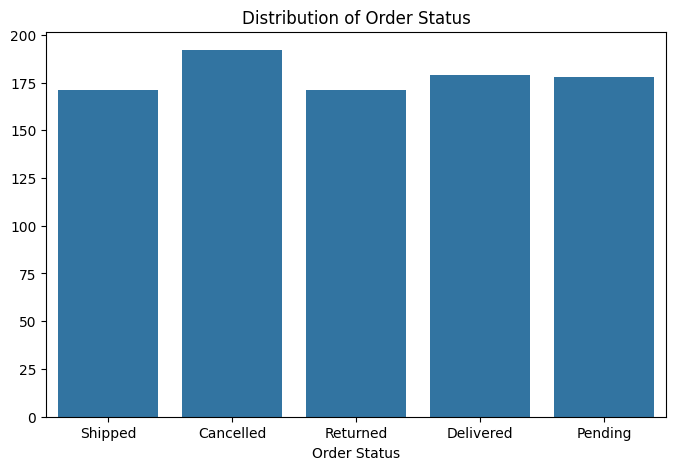

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(x='order_status', data=orders_df)

plt.title('Distribution of Order Status')
plt.xlabel('Order Status')
plt.ylabel('')

plt.show()

#### Distribution of payment methods

-- Payment methods were relatively evenly distributed across the dataset, with `Cash` recording the highest usage and `Debit Card` showing the lowest.

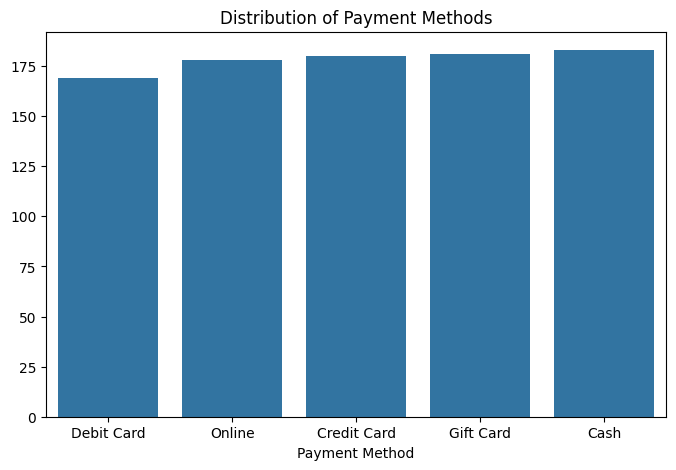

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(x='payment_method', data=orders_df)

plt.title('Distribution of Payment Methods')
plt.xlabel('Payment Method')
plt.ylabel('')

plt.show()

#### Distribution of referral sources

-- `Instagram` and `Email` generated slightly more customer referrals than the other sources.

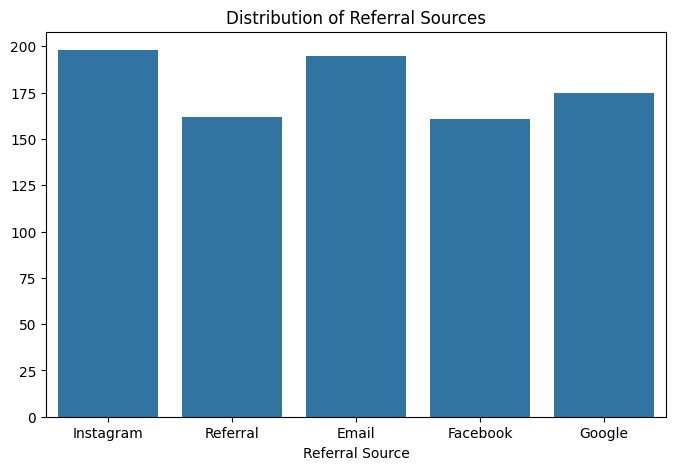

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(x='referral_source', data=orders_df)

plt.title('Distribution of Referral Sources')
plt.xlabel('Referral Source')
plt.ylabel('')

plt.show()

## Bivariate Analysis

#### Monthly Sales Trend Analysis (2023–2025)

-- Sales in `2023` fluctuated throughout the year, with noticeable increases in `May`, `August`, and a major peak in `October`.

-- `2024` showed a more mixed pattern of rises and declines across the months without a strong overall upward or downward movement.

-- `2025` recorded moderate sales performance in the first half of the year before dropping sharply from `July` onward.

-- The sharp decline in `2025` during the second half of the year may indicate incomplete data or reduced recorded transactions for those months.

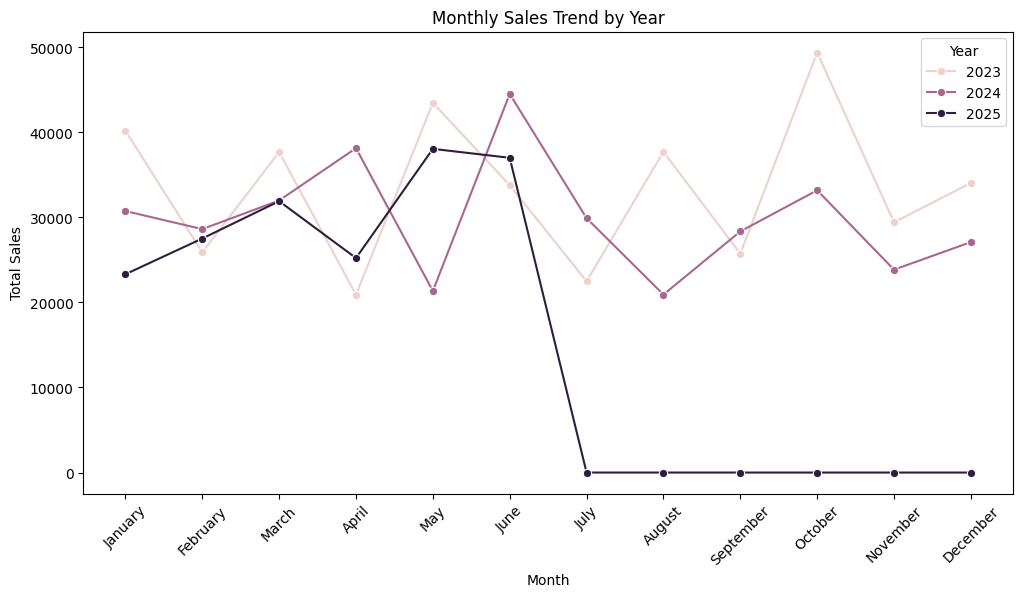

In [11]:
orders_df['date'] = pd.to_datetime(orders_df['date'])

orders_df['year'] = orders_df['date'].dt.year
orders_df['month'] = orders_df['date'].dt.month_name()

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

orders_df['month'] = pd.Categorical(
    orders_df['month'],
    categories=month_order,
    ordered=True
)


monthly_sales = (
    orders_df.groupby(
        ['year', 'month'],
        observed=False
    )['total_price']
    .sum()
    .reset_index()
)


plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales,
    x='month',
    y='total_price',
    hue='year',
    marker='o'
)

plt.title('Monthly Sales Trend by Year')

plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.legend(title='Year')

plt.show()

#### Monthly Quantity Sold Trend Analysis (2023–2025)


-- Quantity sold fluctuated across the months for both `2023` and `2024`, with several visible increases and declines throughout the year.

-- `2023` recorded the highest quantity sold in `October`, while `2024` reached its highest point around `April` and `June`.

-- `2025` showed moderate quantity levels during the first half of the year before dropping sharply to zero from `July` onward.

-- The sharp decline in `2025` from `July` to `December` suggests incomplete or missing records for the second half of the year.


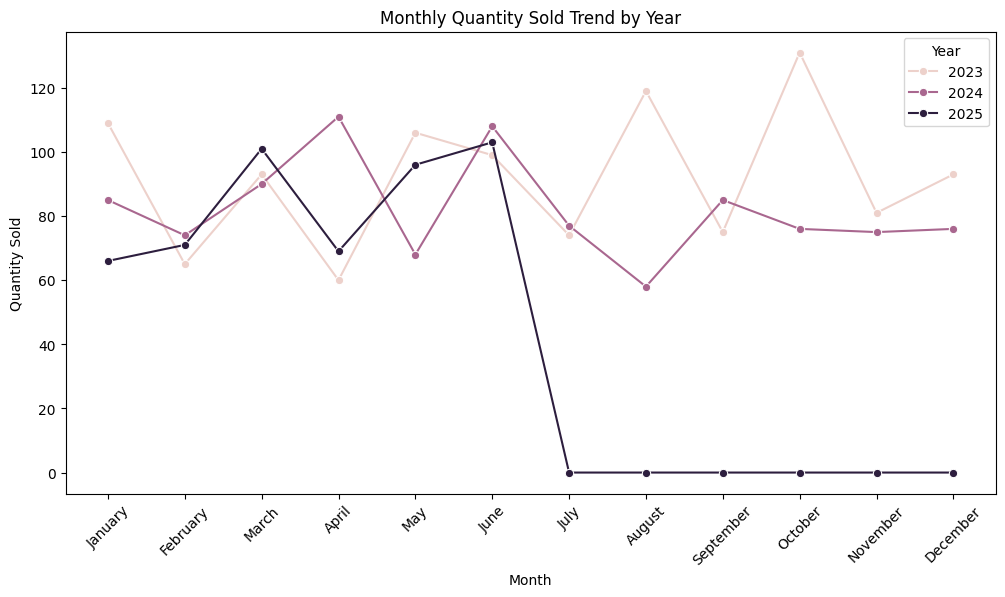

In [12]:
orders_df['date'] = pd.to_datetime(orders_df['date'])

orders_df['year'] = orders_df['date'].dt.year
orders_df['month'] = orders_df['date'].dt.month_name()

month_order = [
    'January', 'February', 'March', 'April',
    'May', 'June', 'July', 'August',
    'September', 'October', 'November', 'December'
]

orders_df['month'] = pd.Categorical(
    orders_df['month'],
    categories=month_order,
    ordered=True
)

monthly_quantity = (
    orders_df.groupby(
        ['year', 'month'],
        observed=False
    )['quantity']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_quantity,
    x='month',
    y='quantity',
    hue='year',
    marker='o'
)

plt.title('Monthly Quantity Sold Trend by Year')

plt.xlabel('Month')
plt.ylabel('Quantity Sold')

plt.xticks(rotation=45)

plt.legend(title='Year')

plt.show()

#### Total sales by product

-- `Printer` generated the highest total sales among the product categories, while `Phone` and `Desk` recorded the lowest overall sales.

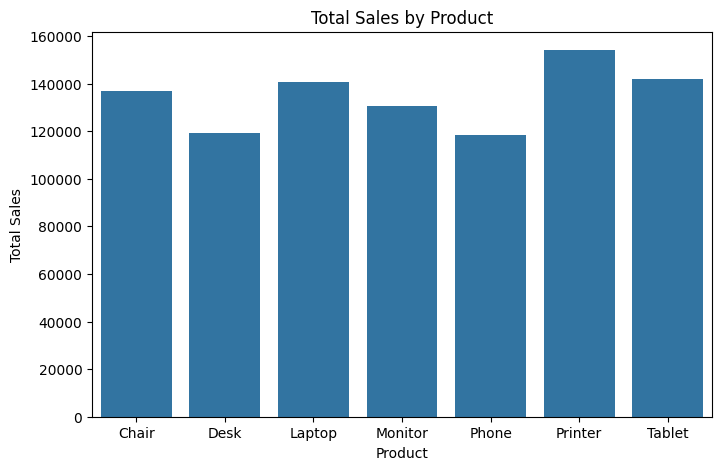

In [13]:
product_sales = (
    orders_df.groupby('product')['total_price']
    .sum()
    .reset_index()
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=product_sales,
    x='product',
    y='total_price'
)

plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.ylabel('Total Sales')

plt.show()

#### Referral Source vs Order Status

-- `Instagram` recorded the highest number of pending orders, while shipped orders remained comparatively lower than several other referral sources.

-- `Referral` traffic showed the highest shipped orders among the referral sources, but also had relatively lower delivered and pending orders.

-- `Email` generated the highest number of delivered orders, although cancelled orders were also relatively high for that source.

-- `Facebook` displayed one of the most balanced distributions across the different order statuses, with no extreme highs or lows.

-- `Google` showed relatively high cancelled and pending orders compared to delivered and returned orders.

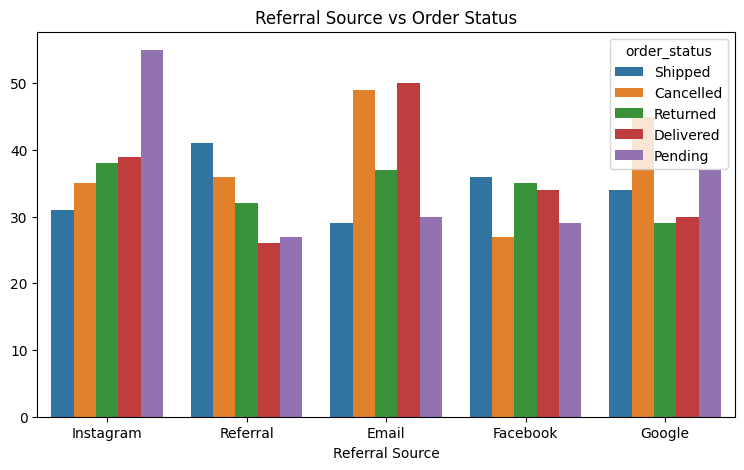

In [14]:
plt.figure(figsize=(9,5))

sns.countplot(x='referral_source', hue='order_status', data=orders_df)

plt.title('Referral Source vs Order Status')
plt.xlabel('Referral Source')
plt.ylabel('')

plt.show()

#### Payment method vs Order status

-- `Debit Card` recorded relatively high returned and delivered orders, while shipped orders remained lower compared to several other payment methods.

-- `Online` payments showed the highest delivered orders among the payment methods, although cancelled orders were also relatively high.

-- `Credit Card` transactions recorded the highest cancelled orders, while delivered orders remained comparatively moderate.

-- `Gift Card` payments showed strong shipped and returned order counts, but had the lowest delivered orders among the payment methods.

-- `Cash` payments displayed a relatively balanced distribution across most order statuses, with slightly higher pending and returned orders.

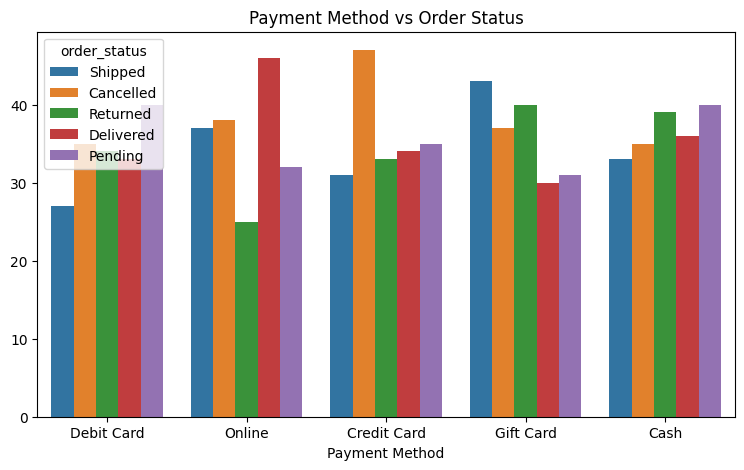

In [15]:
plt.figure(figsize=(9,5))

sns.countplot(x='payment_method', hue='order_status', data=orders_df)

plt.title('Payment Method vs Order Status')
plt.xlabel('Payment Method')
plt.ylabel('')

plt.show()

## Correlation Analysis

-- `unit_price` and `total_price` show the strongest positive correlation (0.71) among the numerical variables.

-- `quantity` and `items_in_cart` show a moderate positive relationship (0.64), indicating they tend to increase together.

-- `unit_price` shows very weak correlation with both `quantity` and `items_in_cart`, suggesting a limited linear relationship between these variables.

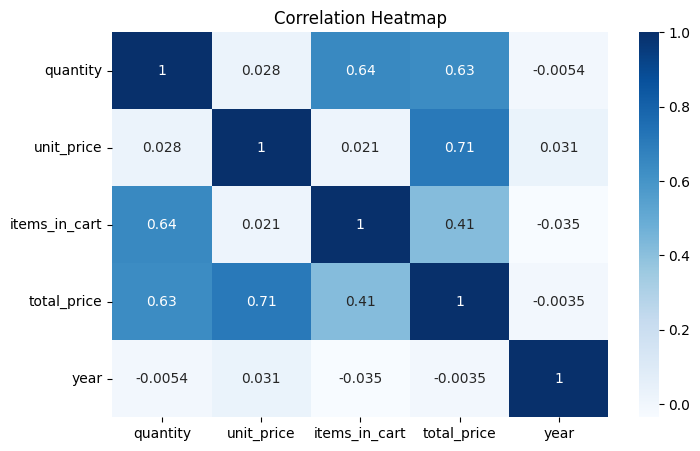

In [16]:
corr_matrix = orders_df.corr(numeric_only=True)

plt.figure(figsize=(8,5))

sns.heatmap(corr_matrix, annot=True, cmap='Blues')

plt.title('Correlation Heatmap')

plt.show()

## Outlier Detection

Outlier detection was primarily performed on the `total_price` column, as it represents the main continuous numerical variable in the dataset. Other numerical variables, such as `quantity` and `items_in_cart,` contain relatively small and limited ranges, while `unit_price` directly contributes to the calculation of `total_price`. Therefore, `total_price` provided the most meaningful basis for identifying unusually high or extreme transaction values.

Total price:

-- Most `total_price` values fall within a moderate range, with the median located near the center of the distribution.

-- Only a negligible number (6 orders) of high-value outliers are present above the upper whisker, indicating very few unusually expensive orders.

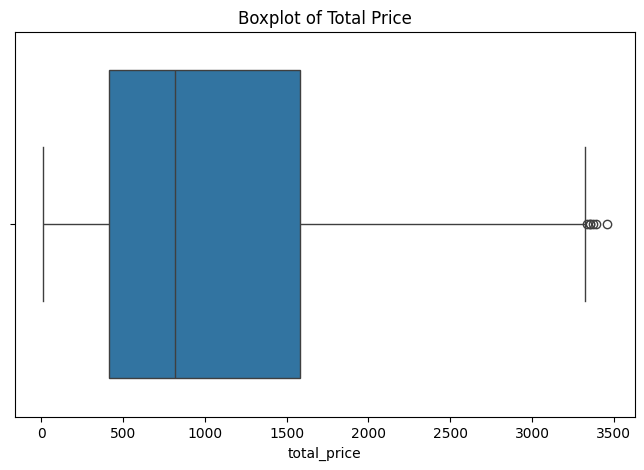

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x=orders_df['total_price'])

plt.title('Boxplot of Total Price')

plt.show()

In [18]:
Q1 = orders_df['total_price'].quantile(0.25)
Q3 = orders_df['total_price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = orders_df[
    (orders_df['total_price'] < lower_bound) |
    (orders_df['total_price'] > upper_bound)
]

len(outliers)

6

# EDA Summary and Insights

-- Product categories, payment methods, and referral sources were relatively balanced across the dataset without extreme dominance from any single category.

-- `Printer` generated the highest total sales among the product categories, while `Phone` and `Desk` recorded comparatively lower sales values.

-- Monthly sales and quantity sold followed closely related patterns across the years, suggesting similar movement between sales performance and product quantity trends.

-- `2023` showed larger fluctuations in both sales and quantity sold compared to `2024`, including noticeable peak in `October`(2023).

-- Referral sources displayed different order status patterns, with `Instagram` recording the highest pending orders and `Email` producing the highest delivered orders.

-- Payment methods showed varying order outcomes, with `Online` payments recording the highest delivered orders and `Credit Card` transactions showing relatively higher cancelled orders.

-- Correlation analysis showed the strongest positive relationship between `unit_price` and `total_price`, while weaker relationships existed between `unit_price` and the cart-related variables.

-- Outlier detection revealed only a negligible number of unusually high `total_price` values, indicating relatively stable transaction distributions across the dataset.